# Libraries

In [1]:
import pandas as pd 

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

import sklearn as sk

import statsmodels.api as sm 

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importing Dataset

Task_3_Original = pd.read_csv(r"C:\Users\DELL\Downloads\1) iris.csv")
iris_2_copied = Task_3_Original
iris_2_copied

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
print("Dataset shape:", iris_2_copied.shape)


Dataset shape: (150, 5)


In [5]:
print(iris_2_copied['species'].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [7]:
# Preparing features

N = iris_2_copied.drop('species', axis= 1)



In [ ]:
# Standardizing the features


scaler = StandardScaler()
N_scaled = scaler.fit_transform(N)

In [9]:
# Elbow Method – find optimal k

wcss = [] # Within-Cluster Sum of Squares
K = range(1, 11)


for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(N_scaled)
    wcss.append(kmeans.inertia_)

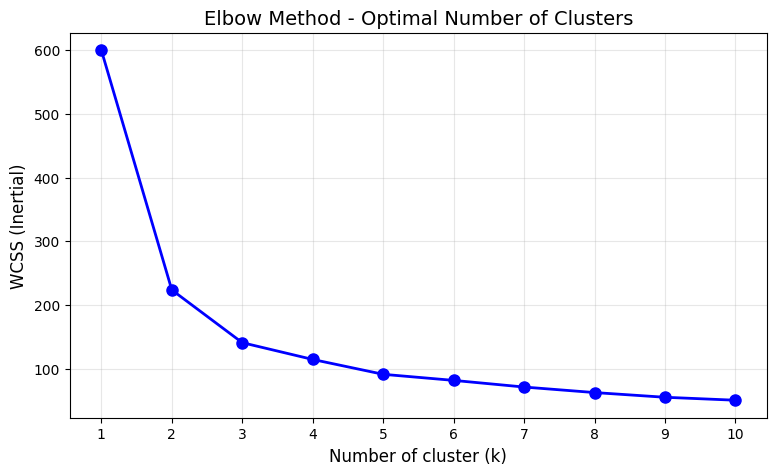

Looking for the 'elbow' point - which is usually k=3 for this dataset


In [10]:
# Plotting Elbow curve

plt.figure(figsize=(9,5))
plt.plot(K, wcss, 'bo-', linewidth = 2, markersize = 8)
plt.xlabel('Number of cluster (k)', fontsize =12)
plt.ylabel('WCSS (Inertial)', fontsize = 12)
plt.title('Elbow Method - Optimal Number of Clusters', fontsize = 14)
plt.xticks(K)
plt.grid(True, alpha =0.3)
plt.show()

print("Looking for the 'elbow' point - which is usually k=3 for this dataset")

<Axes: xlabel='petal_length', ylabel='petal_width'>

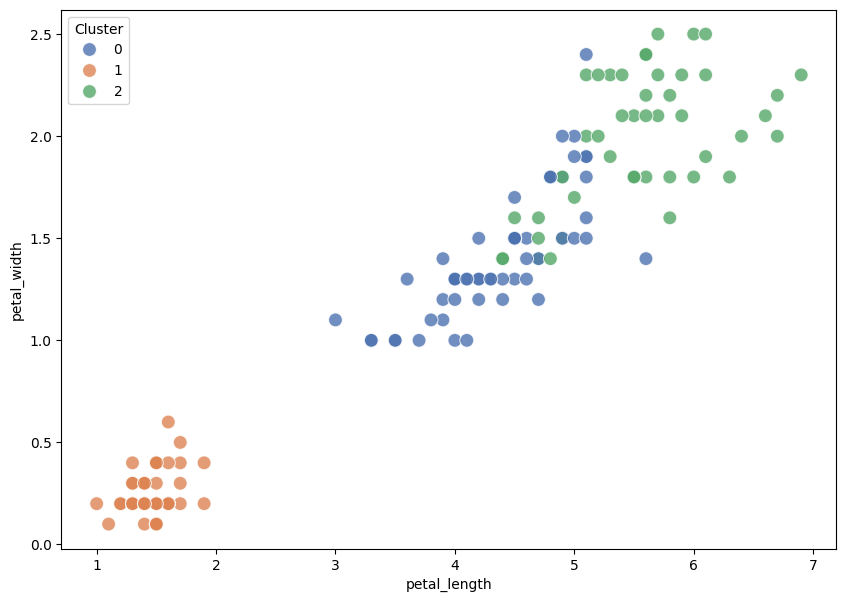

In [11]:
# Applying K-Means with optimal k = 3

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(N_scaled)

iris_2_copied['Cluster'] = clusters


# Visualizing clusters in 2D (petal_length vs petal_width)

plt.figure(figsize = (10,7))

sns.scatterplot(
    x =iris_2_copied['petal_length'], y = iris_2_copied['petal_width'], 
    hue =iris_2_copied['Cluster'], palette='deep', s=100, alpha=0.8
)

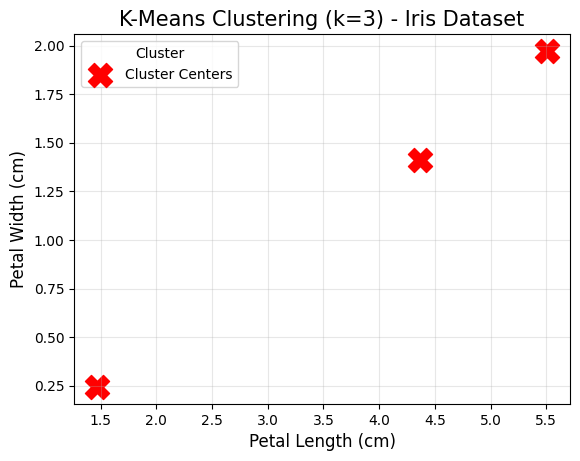

In [12]:
# Plotting cluster centers

centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 2], centers[:, 3], c= 'red', s=300, marker= 'X', label = 'Cluster Centers')

plt.title('K-Means Clustering (k=3) - Iris Dataset', fontsize=15)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

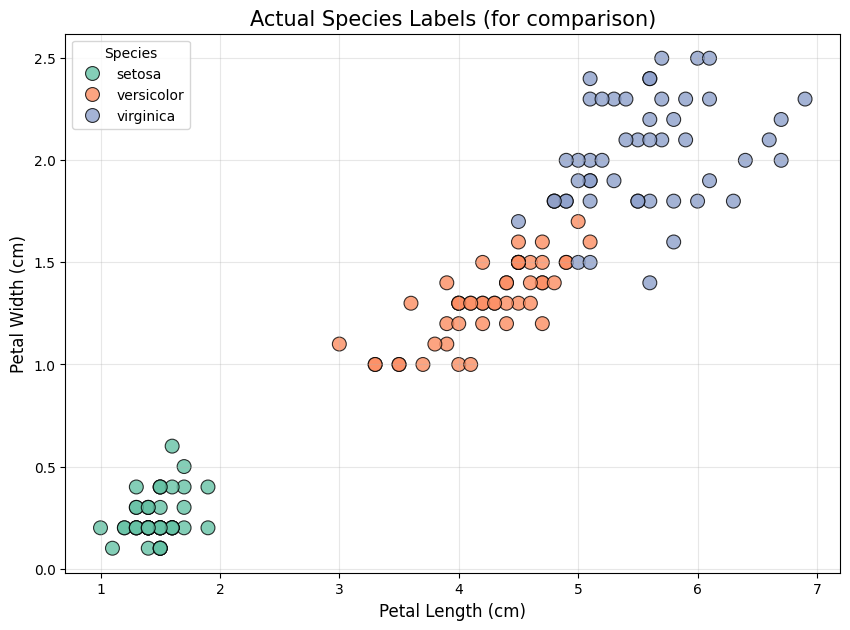

In [13]:
# Comparing clusters with actual species

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=iris_2_copied['petal_length'], y=iris_2_copied['petal_width'],
    hue=iris_2_copied['species'], palette='Set2', s=100, alpha=0.8,
    edgecolor='black'
)
plt.title('Actual Species Labels (for comparison)', fontsize=15)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.legend(title='Species')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Summary : cluster vs actual species

print("\nCluster vs Actual Species Distribution:")
print(pd.crosstab(iris_2_copied['Cluster'], iris_2_copied['species']))


Cluster vs Actual Species Distribution:
species  setosa  versicolor  virginica
Cluster                               
0             0          39         14
1            50           0          0
2             0          11         36
